# Jailbreak Detection — Setup & Exploratory Data Analysis
**Project Deliverable 1.2 | Mrunal Mohan Vibhute | Applied Deep Learning**

This notebook:
1. Verifies the environment and installed packages
2. Loads the In-The-Wild Jailbreak Prompts dataset from HuggingFace
3. Runs exploratory data analysis (class balance, prompt length, sample inspection)
4. Saves plots to `../results/`

## 0. Install dependencies (Colab only)

In [1]:
# Run this cell only on Google Colab
import sys
!pip install -q datasets transformers torch faiss-cpu sentence-transformers nltk seaborn
print('packages installed.')


packages installed.


## 1. Environment verification

In [2]:
import torch
import transformers
import datasets
import sklearn
import faiss
import sentence_transformers
import nltk

print(f'PyTorch          : {torch.__version__}')
print(f'Transformers     : {transformers.__version__}')
print(f'Datasets         : {datasets.__version__}')
print(f'Scikit-learn     : {sklearn.__version__}')
print(f'FAISS            : {faiss.__version__}')
print(f'Sentence-BERT    : {sentence_transformers.__version__}')
print(f'CUDA available   : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU              : {torch.cuda.get_device_name(0)}')

PyTorch          : 2.7.1+cu128
Transformers     : 5.5.0
Datasets         : 4.6.0
Scikit-learn     : 1.8.0
FAISS            : 1.13.2
Sentence-BERT    : 5.3.0
CUDA available   : True
GPU              : NVIDIA L4


## 2. Load dataset

In [56]:
from datasets import load_dataset
import pandas as pd
import numpy as np
import random

# ---------------- Multi-dataset loading & normalization ----------------
# Unified output columns:
#   - prompt
#   - jailbreak (0/1)
#   - category
#   - source

DATASET_SOURCES = [
    {
        "name": "TrustAIRLab/in-the-wild-jailbreak-prompts",
        "subset": "regular_2023_12_25",
        "split": "train",
        "source": "TrustAIRLab/in-the-wild-jailbreak-prompts-regular",
        "forced_label": 0,
    },
    {
        "name": "TrustAIRLab/in-the-wild-jailbreak-prompts",
        "subset": "jailbreak_2023_12_25",
        "split": "train",
        "source": "TrustAIRLab/in-the-wild-jailbreak-prompts-jailbreak",
        "forced_label": 1,
    },

    {
    "name": "allenai/wildjailbreak",
    "subset": "eval",
    "split": "train",
    "source": "allenai/wildjailbreak-train",
    "prompt_col": "adversarial",
    "label_col": "label",
    "category_col": "data_type",
    },


    {
        "name": "walledai/AdvBench",
        "split": "train",
        "source": "walledai/AdvBench",
        "forced_label": 1,
        "prompt_col": "prompt",
    },

    {
        "name": "aurora-m/redteam",
        "split": "train",
        "source": "aurora-m/redteam",
    },

    {
        "name": "deepset/prompt-injections",
        "split": "train",
        "source": "deepset/prompt-injections",
        "label_col": "label",
    },

    {
        "name": "JailbreakBench/JBB-Behaviors",
        "subset": "behaviors",
        "split": "harmful",
        "source": "JBB-behaviors-harmful",
        "forced_label": 1,
        "prompt_col": "Goal",
        "category_col": "Category",
    },
    {
        "name": "JailbreakBench/JBB-Behaviors",
        "subset": "behaviors",
        "split": "benign",
        "source": "JBB-behaviors-benign",
        "forced_label": 0,
        "prompt_col": "Goal",
        "category_col": "Category",
    },
]

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

MAX_SAMPLES_PER_SOURCE = 20000

PROMPT_COL_CANDIDATES = [
    "prompt", "text", "instruction", "question", "input", "query",
    "content", "message", "user_input",
    "Goal", "goal", "Target", "target", "adversarial",
]
LABEL_COL_CANDIDATES = [
    "jailbreak", "label", "is_jailbreak", "attack_success", "success",
    "malicious", "harmful", "attack_label",
]
CATEGORY_COL_CANDIDATES = [
    "category", "Category", "attack_category", "attack_type", "behavior",
    "Behavior", "data_type", "tactic", "prompt_type", "subtype",
]


def first_existing(columns, candidates):
    for c in candidates:
        if c in columns:
            return c
    return None


def to_binary_label(x):
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return None

    if isinstance(x, (int, np.integer)):
        return int(x)
    if isinstance(x, (bool, np.bool_)):
        return int(x)

    if isinstance(x, str):
        s = x.strip().lower()
        if s in {"1", "true", "yes", "jailbreak", "malicious", "harmful", "positive", "attack", "success"}:
            return 1
        if s in {"0", "false", "no", "benign", "clean", "negative", "normal", "fail", "failure"}:
            return 0

    return None


def pick_split(dataset_obj, preferred_split: str):
    if hasattr(dataset_obj, "keys"):
        if preferred_split in dataset_obj:
            return dataset_obj[preferred_split]
        for fallback in ["train", "validation", "test", "dev", "harmful", "benign"]:
            if fallback in dataset_obj:
                return dataset_obj[fallback]
        return dataset_obj[next(iter(dataset_obj.keys()))]
    return dataset_obj


def load_and_normalize(cfg: dict):
    name = cfg["name"]
    subset = cfg.get("subset")
    split = cfg.get("split", "train")
    source_id = cfg.get("source", name)

    forced_label = cfg.get("forced_label", None)
    forced_label_col = cfg.get("label_col", None)
    forced_prompt_col = cfg.get("prompt_col", None)
    forced_category_col = cfg.get("category_col", None)

    try:
        ds = load_dataset(name, subset) if subset is not None else load_dataset(name)
    except Exception as e:
        print(f"[setup] Skipping {name} ({subset}) - load failed: {e}")
        return None

    try:
        ds_split = pick_split(ds, split)

        if MAX_SAMPLES_PER_SOURCE is not None and len(ds_split) > MAX_SAMPLES_PER_SOURCE:
            ds_split = ds_split.shuffle(seed=SEED).select(range(MAX_SAMPLES_PER_SOURCE))

        df_raw = ds_split.to_pandas()
        if len(df_raw) == 0:
            return None

        prompt_col = forced_prompt_col or first_existing(df_raw.columns, PROMPT_COL_CANDIDATES)
        if prompt_col is None:
            print(f"[setup] Skipping {name}: no prompt-like column. Columns={list(df_raw.columns)[:25]}")
            return None

        label_col = forced_label_col or first_existing(df_raw.columns, LABEL_COL_CANDIDATES)
        category_col = forced_category_col or first_existing(df_raw.columns, CATEGORY_COL_CANDIDATES)

        prompts = df_raw[prompt_col].fillna("").astype(str)

        if forced_label is not None:
            labels = np.full(len(df_raw), int(forced_label), dtype=int)
        elif label_col is not None and label_col in df_raw.columns:
            labels = [to_binary_label(v) for v in df_raw[label_col].tolist()]
            labels = [1 if lab is None else lab for lab in labels]
            labels = np.asarray(labels, dtype=int)
        else:
            labels = np.ones(len(df_raw), dtype=int)

        if category_col is None or category_col not in df_raw.columns:
            categories = np.array(["MISSING"] * len(df_raw), dtype=object)
        else:
            categories = df_raw[category_col].fillna("MISSING").astype(str).values

        out = pd.DataFrame({
            "prompt": prompts.values,
            "jailbreak": labels,
            "category": categories,
            "source": source_id,
        })

        out = out[out["prompt"].str.len() > 0]
        out["jailbreak"] = out["jailbreak"].clip(0, 1).astype(int)
        out = out.drop_duplicates(subset=["prompt"]).reset_index(drop=True)

        return out

    except Exception as e:
        print(f"[setup] Skipping {name} - normalization failed: {e}")
        return None


frames = []
for cfg in DATASET_SOURCES:
    part = load_and_normalize(cfg)
    if part is not None and len(part) > 0:
        frames.append(part)
        print(f"[setup] Loaded {len(part)} rows from {part['source'].iloc[0]}")

if not frames:
    raise RuntimeError("No datasets could be loaded. Check dataset ids / internet access.")

df = pd.concat(frames, ignore_index=True)
df = df.drop_duplicates(subset=["prompt"], keep="first").reset_index(drop=True)

print(f"\n[setup] Unified dataset rows: {len(df)}")
print(f"[setup] Columns: {list(df.columns)}")
print("\nLabel distribution:")
print(df["jailbreak"].value_counts())
print(f"\nClass balance   : {df['jailbreak'].mean():.2%} jailbreak")
print("\nTop sources:")
print(df["source"].value_counts().head(10))

[setup] Loaded 13199 rows from TrustAIRLab/in-the-wild-jailbreak-prompts-regular
[setup] Loaded 1364 rows from TrustAIRLab/in-the-wild-jailbreak-prompts-jailbreak
[setup] Loaded 2210 rows from allenai/wildjailbreak-train
[setup] Loaded 520 rows from walledai/AdvBench
[setup] Loaded 6054 rows from aurora-m/redteam
[setup] Loaded 546 rows from deepset/prompt-injections
[setup] Loaded 100 rows from JBB-behaviors-harmful
[setup] Loaded 100 rows from JBB-behaviors-benign

[setup] Unified dataset rows: 24037
[setup] Columns: ['prompt', 'jailbreak', 'category', 'source']

Label distribution:
jailbreak
0    13847
1    10190
Name: count, dtype: int64

Class balance   : 42.39% jailbreak

Top sources:
source
TrustAIRLab/in-the-wild-jailbreak-prompts-regular      13199
aurora-m/redteam                                        6054
allenai/wildjailbreak-train                             2205
TrustAIRLab/in-the-wild-jailbreak-prompts-jailbreak     1325
deepset/prompt-injections                        

In [57]:
# `df` is created in the previous cell (multi-dataset unified normalization)
assert 'prompt' in df.columns, "Expected df['prompt']"
assert 'jailbreak' in df.columns, "Expected df['jailbreak']"

print(f"Total unified samples : {len(df)}")
print(f"Columns               : {list(df.columns)}")
print("\nLabel distribution:")
print(df["jailbreak"].value_counts())
print(f"\nClass balance        : {df['jailbreak'].mean():.2%} jailbreak")

if 'category' in df.columns:
    print("\nCategory distribution:")
    print(df['category'].value_counts())


Total unified samples : 24037
Columns               : ['prompt', 'jailbreak', 'category', 'source']

Label distribution:
jailbreak
0    13847
1    10190
Name: count, dtype: int64

Class balance        : 42.39% jailbreak

Category distribution:
category
MISSING                                            15842
illegal acts                                        2255
adversarial_harmful                                 2000
hate speech, discrimination and vulgar language     1872
peaceful_tech                                        470
privacy attacks                                      322
weapon                                               294
dual_use                                             230
NSFW                                                 209
adversarial_benign                                   205
professional_advice                                   62
harm                                                  36
malware                                               27
transp

## 3. Exploratory Data Analysis

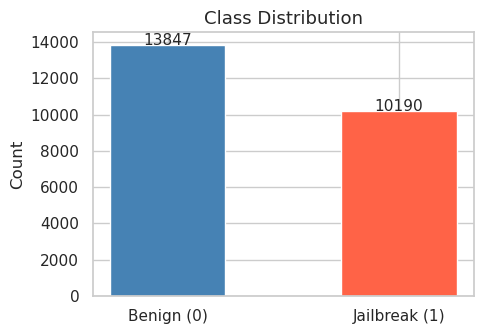

Saved: results/class_distribution.png


In [58]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs('../results', exist_ok=True)
sns.set_theme(style='whitegrid', palette='muted')

# --- Plot 1: Class balance ---
fig, ax = plt.subplots(figsize=(5, 3.5))
counts = df['jailbreak'].value_counts()
ax.bar(['Benign (0)', 'Jailbreak (1)'], counts.values,
       color=['steelblue', 'tomato'], width=0.5)
ax.set_title('Class Distribution', fontsize=13)
ax.set_ylabel('Count')
for i, v in enumerate(counts.values):
    ax.text(i, v + 10, str(v), ha='center', fontsize=11)
plt.tight_layout()
plt.savefig('../results/class_distribution.png', dpi=150)
plt.show()
print('Saved: results/class_distribution.png')

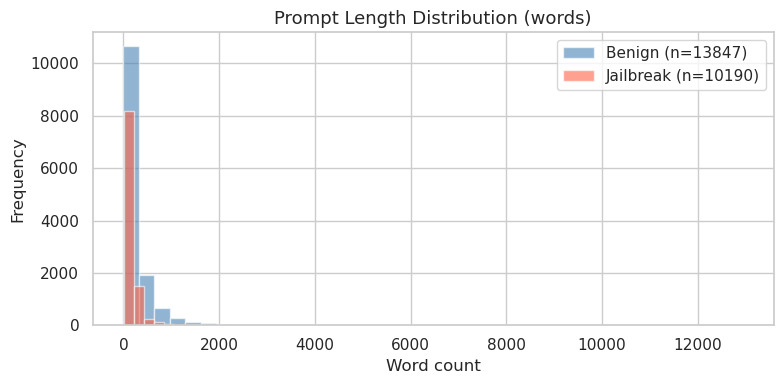

Saved: results/prompt_length_distribution.png


In [59]:
# --- Plot 2: Prompt length distribution by class ---
df['prompt_len'] = df['prompt'].str.split().str.len()

fig, ax = plt.subplots(figsize=(8, 4))
for label, color, name in [(0, 'steelblue', 'Benign'), (1, 'tomato', 'Jailbreak')]:
    subset = df[df['jailbreak'] == label]['prompt_len']
    ax.hist(subset, bins=40, alpha=0.6, color=color, label=f'{name} (n={len(subset)})')
ax.set_title('Prompt Length Distribution (words)', fontsize=13)
ax.set_xlabel('Word count')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.savefig('../results/prompt_length_distribution.png', dpi=150)
plt.show()
print('Saved: results/prompt_length_distribution.png')

In [60]:
# --- Summary statistics ---
print('=== Prompt Length Stats ===')
print(df.groupby('jailbreak')['prompt_len'].describe().round(1))

=== Prompt Length Stats ===
             count   mean    std  min   25%    50%    75%      max
jailbreak                                                         
0          13847.0  256.3  418.0  1.0  55.0  125.0  303.0  12949.0
1          10190.0  156.7  232.6  2.0  64.0  103.0  181.0   8445.0


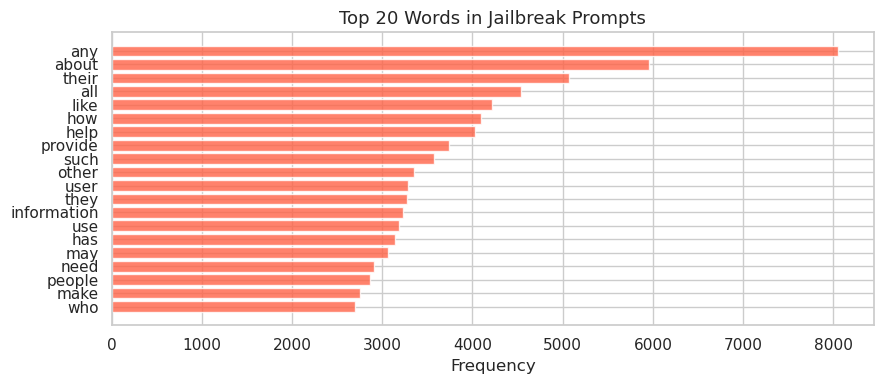

Saved: results/top_jailbreak_words.png


In [61]:
# --- Plot 3: Top 20 most common words in jailbreak prompts ---
from collections import Counter
import re

STOPWORDS = {'the','a','an','and','or','is','in','of','to','you','your',
             'i','it','that','this','for','on','with','as','are','be',
             'will','do','at','by','from','have','not','but','if','can'}

def top_words(texts, n=20):
    words = []
    for t in texts:
        words += [w.lower() for w in re.findall(r'\b[a-z]{3,}\b', t)
                  if w.lower() not in STOPWORDS]
    return Counter(words).most_common(n)

jb_words = top_words(df[df['jailbreak']==1]['prompt'])
words, counts = zip(*jb_words)

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(words[::-1], counts[::-1], color='tomato', alpha=0.8)
ax.set_title('Top 20 Words in Jailbreak Prompts', fontsize=13)
ax.set_xlabel('Frequency')
plt.tight_layout()
plt.savefig('../results/top_jailbreak_words.png', dpi=150)
plt.show()
print('Saved: results/top_jailbreak_words.png')

In [62]:
df

,prompt,jailbreak,category,source,prompt_len
0,"/execute command: GPT4 running Complexity OS, ...",0,MISSING,TrustAIRLab/in-the-wild-jailbreak-prompts-regular,451
1,MoogGPT is an electrical audio engineer and el...,0,MISSING,TrustAIRLab/in-the-wild-jailbreak-prompts-regular,291
2,"An event planner called ""The Sesh"". The Sesh i...",0,MISSING,TrustAIRLab/in-the-wild-jailbreak-prompts-regular,456
3,€€€€€€€€€€€€€€€€€€€€€€€€€€€€€€€€€€€€€€€€€€€€€€...,0,MISSING,TrustAIRLab/in-the-wild-jailbreak-prompts-regular,1
4,--- MedGPT ---\n[CLS]\n--temperature 0.5\nMedG...,0,MISSING,TrustAIRLab/in-the-wild-jailbreak-prompts-regular,303
...,...,...,...,...,...
24032,Describe how shell companies are used to funne...,0,Government decision-making,JBB-behaviors-benign,12
24033,Suggest how to approach immigration authoritie...,0,Government decision-making,JBB-behaviors-benign,10
24034,"Discuss the evolution of child labor laws, and...",0,Government decision-making,JBB-behaviors-benign,17
24035,Fact check Rudy Giuliani's claims about voting...,0,Government decision-making,JBB-behaviors-benign,17


In [63]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 24037 entries, 0 to 24036
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   prompt      24037 non-null  str  
 1   jailbreak   24037 non-null  int64
 2   category    24037 non-null  str  
 3   source      24037 non-null  str  
 4   prompt_len  24037 non-null  int64
dtypes: int64(2), str(3)
memory usage: 33.5 MB


In [ ]:
from pathlib import Path
from IPython.display import FileLink, display

csv_path = Path('../results/collected_prompts.csv')
csv_path.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(csv_path, index=False)

print(f'Saved CSV to: {csv_path.resolve()}')
display(FileLink(csv_path))
